# 🏠 Task 1: Build & Evaluate a Linear Regression Model
## House Price Predictor — California Housing Dataset
**Maincraft Internship | AI & Machine Learning**

---
This notebook walks through the full Machine Learning workflow:
1. Setup & Imports
2. Dataset Loading
3. Exploratory Data Analysis (EDA)
4. Preprocessing & Feature Scaling
5. Model Training (Linear Regression)
6. Evaluation (MAE, RMSE, R²)
7. Saving the Model
8. Conclusions & Improvement Ideas

---
## 1. Setup & Imports

In [1]:
# Standard library
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model persistence
import pickle
import os

# Display settings
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ All libraries loaded successfully!')
print(f'NumPy version    : {np.__version__}')
print(f'Pandas version   : {pd.__version__}')
print(f'Matplotlib version: {matplotlib.__version__}')

✅ All libraries loaded successfully!
NumPy version    : 2.0.2
Pandas version   : 2.3.3
Matplotlib version: 3.9.4


---
## 2. Dataset Loading

The **California Housing Dataset** contains data from the 1990 California census.
Each row represents a block group (smallest geographical unit for census data).

| Feature | Description |
|---|---|
| MedInc | Median income in block group |
| HouseAge | Median house age in block group |
| AveRooms | Average number of rooms per household |
| AveBedrms | Average number of bedrooms per household |
| Population | Block group population |
| AveOccup | Average number of household members |
| Latitude | Block group latitude |
| Longitude | Block group longitude |

**Target:** MedHouseVal — Median house value in $100,000s

In [2]:
# Load the dataset
california = fetch_california_housing()

# Create a DataFrame
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target  # Target column

print('📊 Dataset loaded successfully!')
print(f'Shape          : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Features       : {list(california.feature_names)}')
print(f'Target         : MedHouseVal (Median House Value in $100,000s)')
df.head(10)

📊 Dataset loaded successfully!
Shape          : 20640 rows × 9 columns
Features       : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target         : MedHouseVal (Median House Value in $100,000s)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,4.5260
1,8.3014,21.0000,6.2381,0.9719,2401.0000,2.1098,37.8600,-122.2200,3.5850
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,3.5210
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,3.4130
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,3.4220
5,4.0368,52.0000,4.7617,1.1036,413.0000,2.1399,37.8500,-122.2500,2.6970
6,3.6591,52.0000,4.9319,0.9514,1094.0000,2.1284,37.8400,-122.2500,2.9920
7,3.1200,52.0000,4.7975,1.0618,1157.0000,1.7883,37.8400,-122.2500,2.4140
8,2.0804,42.0000,4.2941,1.1176,1206.0000,2.0269,37.8400,-122.2600,2.2670
9,3.6912,52.0000,4.9706,0.9902,1551.0000,2.1723,37.8400,-122.2500,2.6110


---
## 3. Exploratory Data Analysis (EDA)

In [3]:
# Basic statistics
print('=== Dataset Info ===')
print(df.info())
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

=== Statistical Summary ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,3.8707,28.6395,5.4290,1.0967,1425.4767,3.0707,35.6319,-119.5697,2.0686
std,1.8998,12.5856,2.4742,0.4739,1132.4621,10.3860,2.1360,2.0035,1.1540
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500,0.1500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000,1.1960
50%,3.5348,29.0000,5.2291,1.0488,1166.0000,2.8181,34.2600,-118.4900,1.7970
75%,4.7432,37.0000,6.0524,1.0995,1725.0000,3.2823,37.7100,-118.0100,2.6472
max,15.0001,52.0000,141.9091,34.0667,35682.0000,1243.3333,41.9500,-114.3100,5.0000


In [4]:
# Missing value check
missing = df.isnull().sum()
print('=== Missing Values ===')
if missing.sum() == 0:
    print('✅ No missing values found! The dataset is clean.')
else:
    print(missing[missing > 0])

=== Missing Values ===
✅ No missing values found! The dataset is clean.


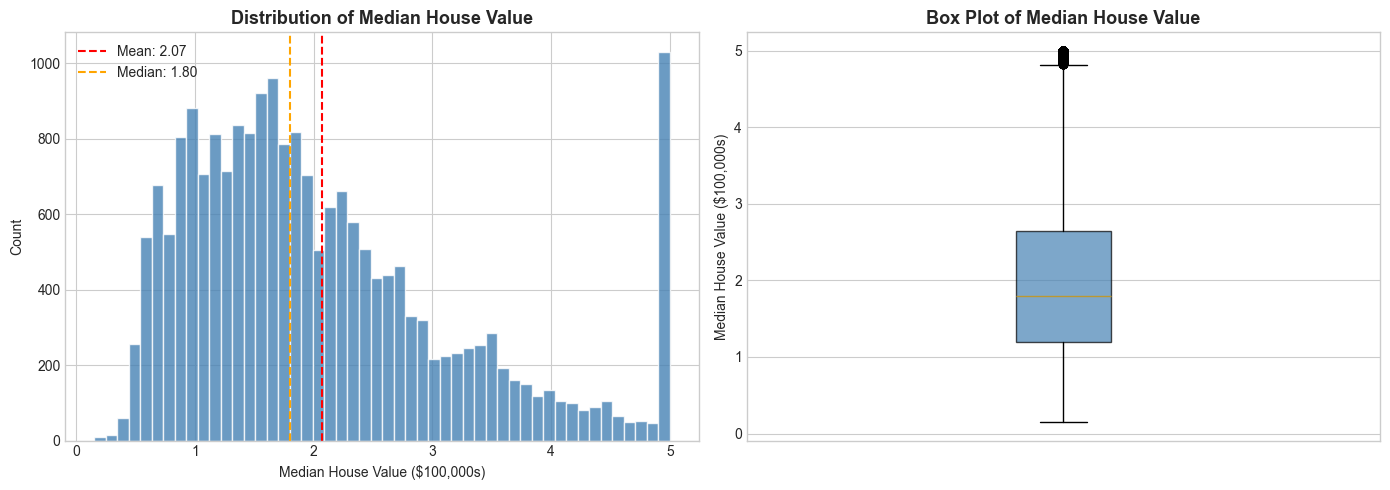

Target mean   : 2.0686 ($206,856)
Target median : 1.7970 ($179,700)
Target std    : 1.1540


In [5]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Median House Value', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median House Value ($100,000s)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', label=f'Mean: {df["MedHouseVal"].mean():.2f}')
axes[0].axvline(df['MedHouseVal'].median(), color='orange', linestyle='--', label=f'Median: {df["MedHouseVal"].median():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['MedHouseVal'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot of Median House Value', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Median House Value ($100,000s)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Target mean   : {df["MedHouseVal"].mean():.4f} (${df["MedHouseVal"].mean()*100000:,.0f})')
print(f'Target median : {df["MedHouseVal"].median():.4f} (${df["MedHouseVal"].median()*100000:,.0f})')
print(f'Target std    : {df["MedHouseVal"].std():.4f}')

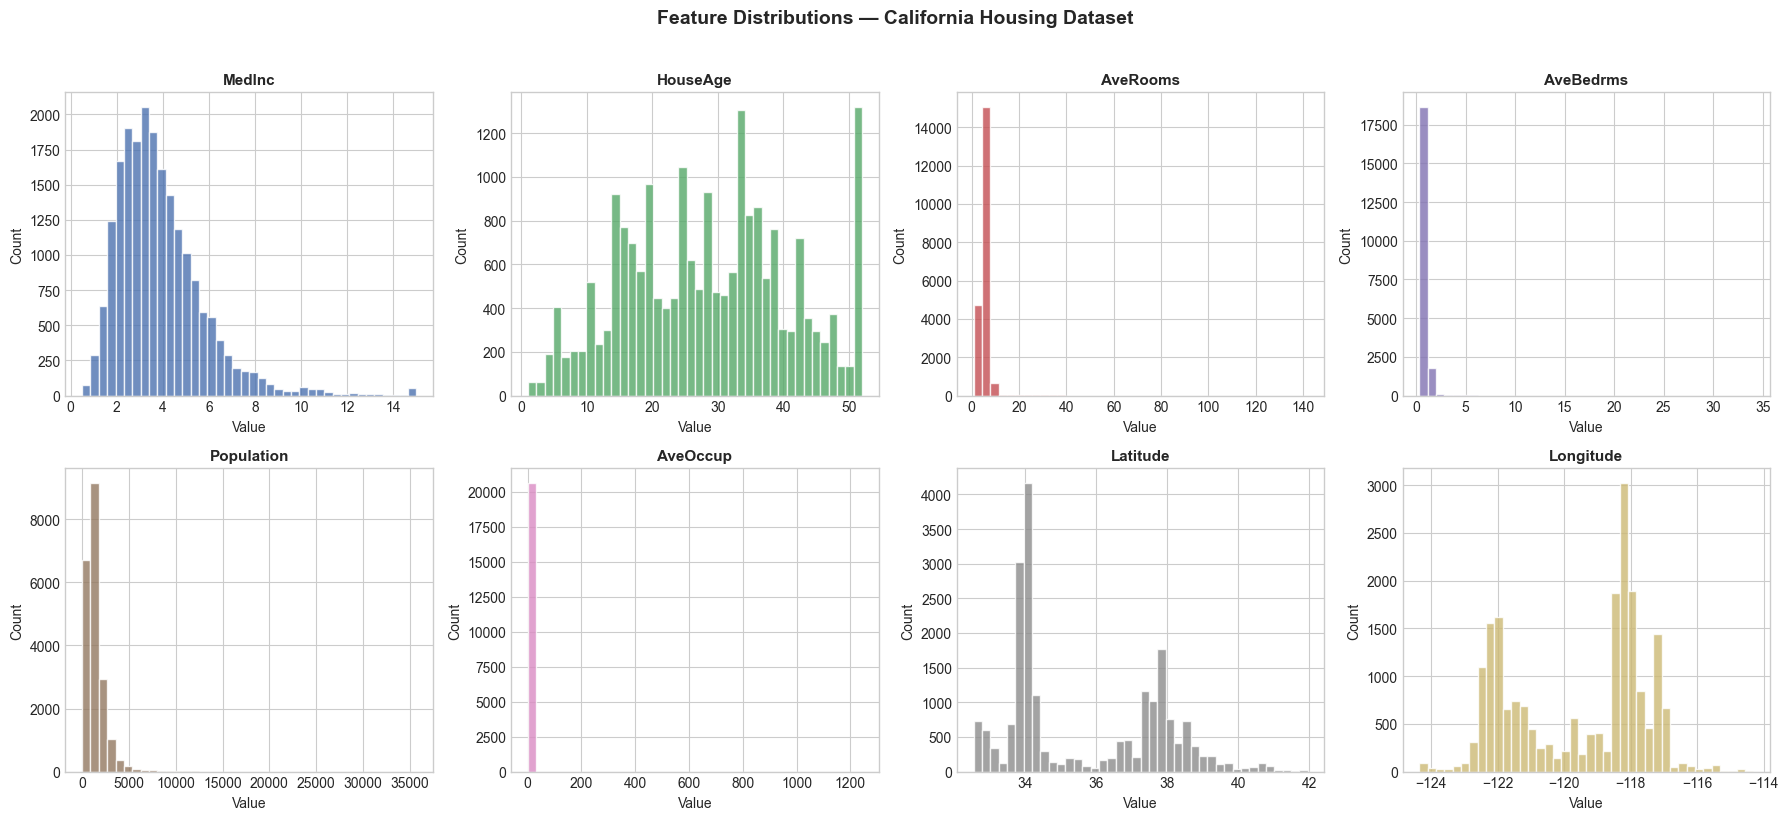

In [6]:
# Feature distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

feature_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3', '#8C8C8C', '#CCB974']

for i, feature in enumerate(california.feature_names):
    axes[i].hist(df[feature], bins=40, color=feature_colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions — California Housing Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

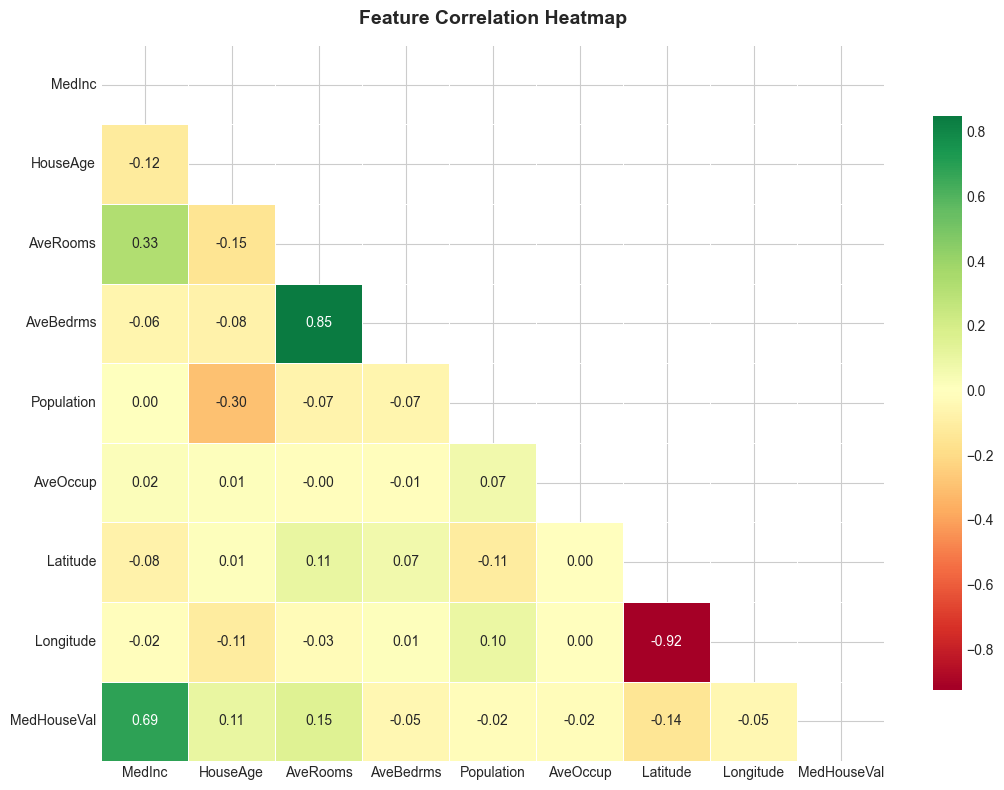

=== Top Features Correlated with MedHouseVal ===
MedInc      : +█████████████ (+0.6881)
AveRooms    : +███ (+0.1519)
HouseAge    : +██ (+0.1056)
AveOccup    : - (-0.0237)
Population  : - (-0.0246)
Longitude   : - (-0.0460)
AveBedrms   : - (-0.0467)
Latitude    : -██ (-0.1442)


In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(11, 8))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='RdYlGn', 
    center=0, 
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Print top correlations with target
print('=== Top Features Correlated with MedHouseVal ===')
target_corr = corr_matrix['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 20)
    direction = '+' if val > 0 else '-'
    print(f'{feat:12s}: {direction}{bar} ({val:+.4f})')

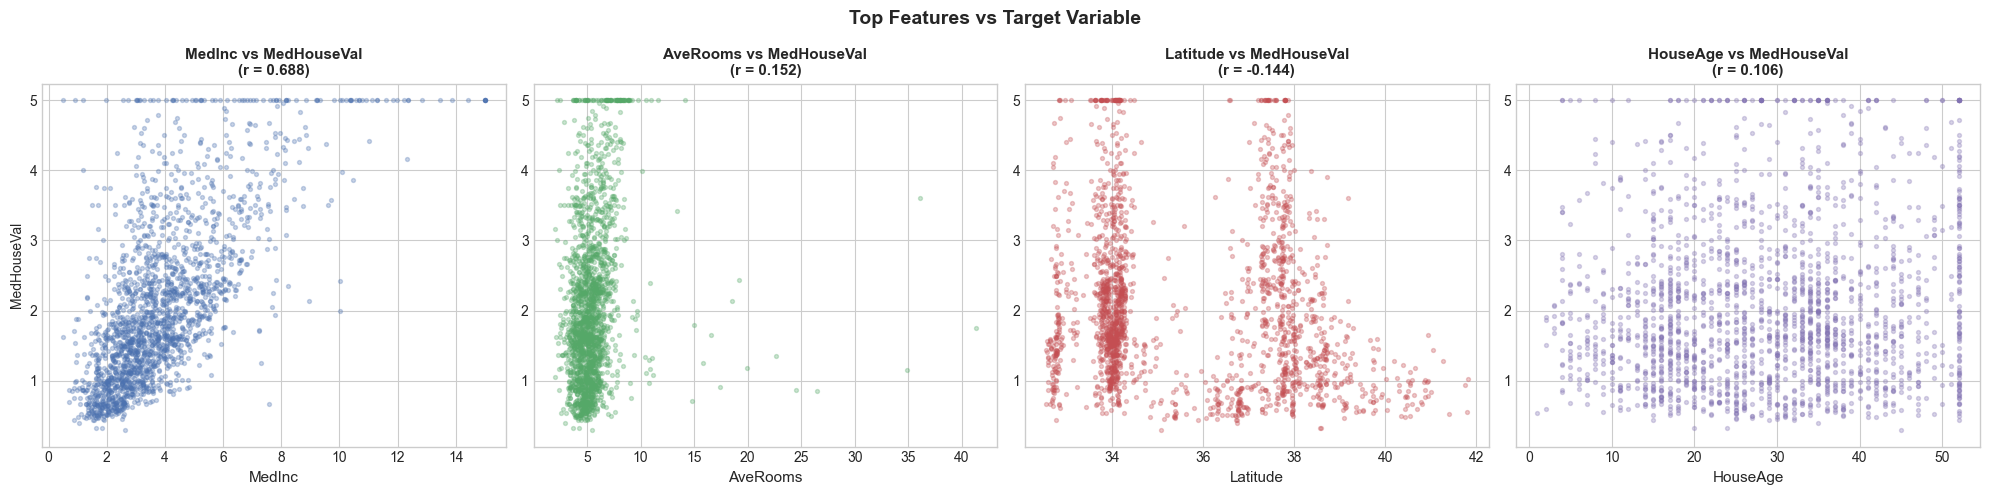

In [8]:
# Scatter plots: Top features vs Target
top_features = target_corr.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, feat in enumerate(top_features):
    # Sample 2000 points to avoid overplotting
    sample = df.sample(2000, random_state=42)
    axes[i].scatter(sample[feat], sample['MedHouseVal'], alpha=0.3, s=8, color=colors[i])
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('MedHouseVal' if i == 0 else '')
    axes[i].set_title(f'{feat} vs MedHouseVal\n(r = {df[feat].corr(df["MedHouseVal"]):.3f})', fontsize=11, fontweight='bold')

plt.suptitle('Top Features vs Target Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_scatter_plots.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Preprocessing & Feature Scaling

In [9]:
# Separate features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')

# Train/Test Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'\n✂️  Train/Test Split (80/20):')
print(f'Training samples   : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test samples       : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

# Feature Scaling — StandardScaler (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)          # only transform on test (no leakage!)

print(f'\n📏 StandardScaler applied:')
print(f'Training mean (before scaling): {X_train.mean().mean():.4f}')
print(f'Training mean (after scaling) : {X_train_scaled.mean():.6f}')
print(f'Training std  (after scaling) : {X_train_scaled.std():.6f}')

Features shape : (20640, 8)
Target shape   : (20640,)

✂️  Train/Test Split (80/20):
Training samples   : 16512 (80.0%)
Test samples       : 4128 (20.0%)

📏 StandardScaler applied:
Training mean (before scaling): 173.0790
Training mean (after scaling) : 0.000000
Training std  (after scaling) : 1.000000


---
## 5. Model Training — Linear Regression

**Linear Regression** fits a hyperplane: 
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

Where:
- $\hat{y}$ = predicted house value
- $\beta_0$ = intercept (bias term)
- $\beta_i$ = coefficient for feature $x_i$

The model minimizes the **Mean Squared Error (MSE)** using the **Ordinary Least Squares (OLS)** method.

✅ Model trained successfully!

Model Intercept (β₀) : 2.0719

Feature Coefficients :
   Feature  Coefficient
    MedInc       0.8544
 AveBedrms       0.3393
  HouseAge       0.1225
Population      -0.0023
  AveOccup      -0.0408
  AveRooms      -0.2944
 Longitude      -0.8698
  Latitude      -0.8969


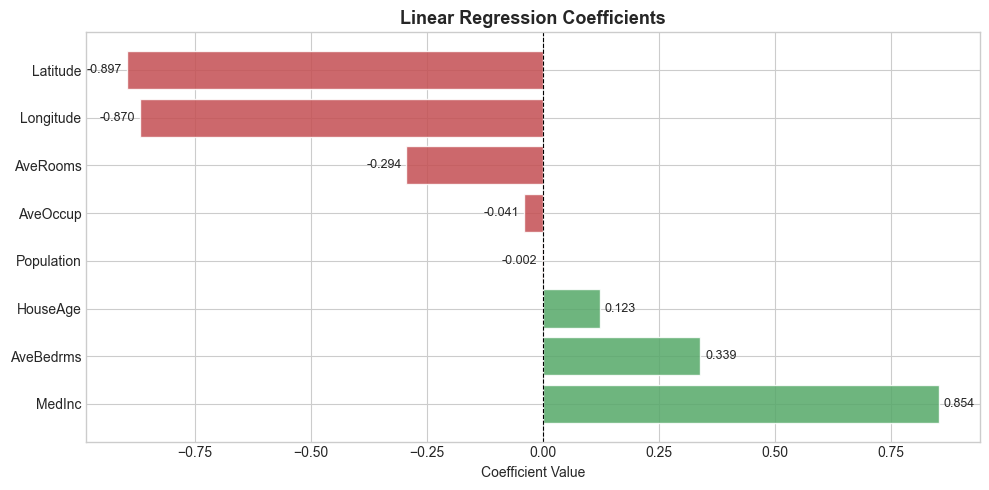

In [10]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('✅ Model trained successfully!')
print(f'\nModel Intercept (β₀) : {model.intercept_:.4f}')
print(f'\nFeature Coefficients :')
coef_df = pd.DataFrame({
    'Feature': california.feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#55A868' if c > 0 else '#C44E52' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Linear Regression Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
for bar, val in zip(bars, coef_df['Coefficient']):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('model_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Model Evaluation

We evaluate using 3 key metrics:

| Metric | Formula | Meaning |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y - \hat{y}|$ | Average absolute error |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y - \hat{y})^2}$ | Penalizes large errors |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Variance explained by model (higher = better) |

In [11]:
# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

# Calculate metrics
def evaluate(y_true, y_pred, split_name='Test'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n📊 {split_name} Set Metrics:')
    print(f'  MAE  (Mean Absolute Error)      : {mae:.4f}  (${mae*100000:,.0f} avg error)')
    print(f'  RMSE (Root Mean Squared Error)  : {rmse:.4f}  (${rmse*100000:,.0f})')
    print(f'  R²   (Coefficient of Determination): {r2:.4f}  ({r2*100:.1f}% variance explained)')
    return mae, rmse, r2

train_mae, train_rmse, train_r2 = evaluate(y_train, y_train_pred, 'Training')
test_mae,  test_rmse,  test_r2  = evaluate(y_test,  y_test_pred,  'Test')

# Summary table
print('\n' + '='*55)
print(f'{"Metric":<30} {"Train":>10} {"Test":>10}')
print('='*55)
print(f'{"MAE":30} {train_mae:>10.4f} {test_mae:>10.4f}')
print(f'{"RMSE":30} {train_rmse:>10.4f} {test_rmse:>10.4f}')
print(f'{"R² Score":30} {train_r2:>10.4f} {test_r2:>10.4f}')
print('='*55)


📊 Training Set Metrics:
  MAE  (Mean Absolute Error)      : 0.5286  ($52,863 avg error)
  RMSE (Root Mean Squared Error)  : 0.7197  ($71,968)
  R²   (Coefficient of Determination): 0.6126  (61.3% variance explained)

📊 Test Set Metrics:
  MAE  (Mean Absolute Error)      : 0.5332  ($53,320 avg error)
  RMSE (Root Mean Squared Error)  : 0.7456  ($74,558)
  R²   (Coefficient of Determination): 0.5758  (57.6% variance explained)

Metric                              Train       Test
MAE                                0.5286     0.5332
RMSE                               0.7197     0.7456
R² Score                           0.6126     0.5758


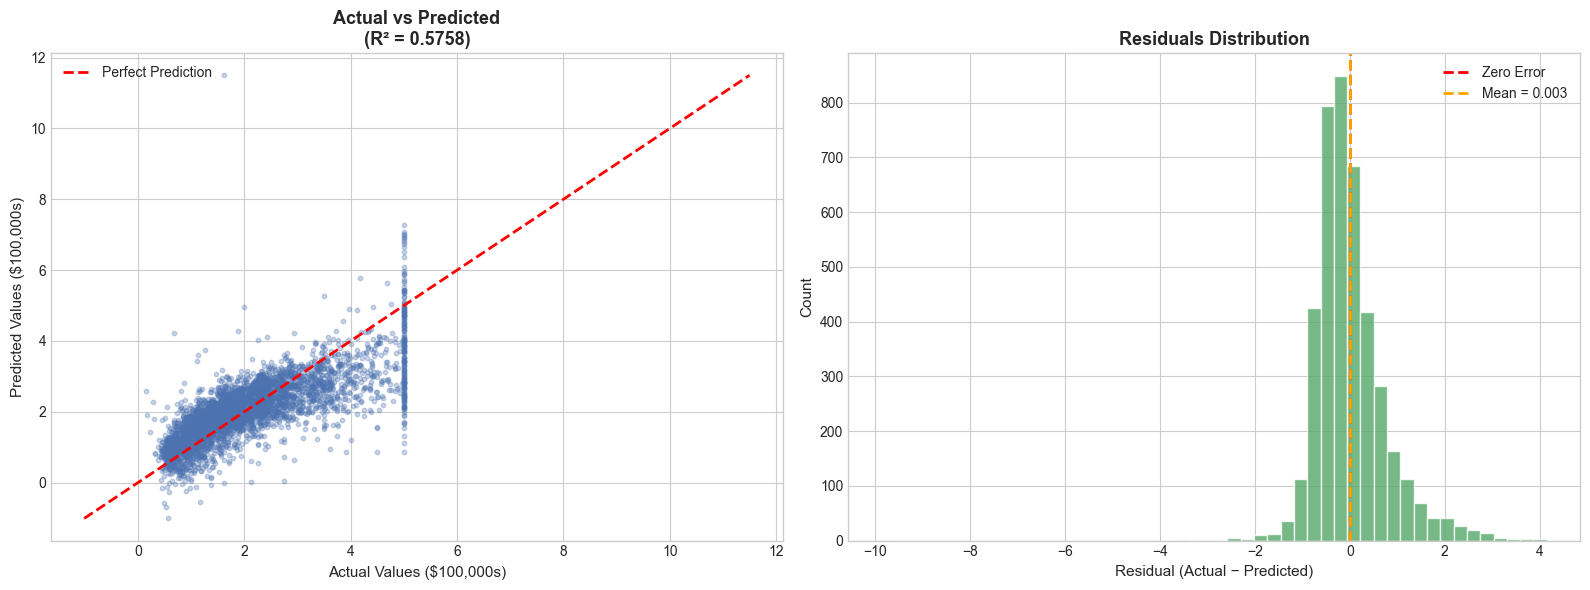

In [12]:
# Visualization 1: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='#4C72B0')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values ($100,000s)', fontsize=11)
axes[0].set_ylabel('Predicted Values ($100,000s)', fontsize=11)
axes[0].set_title(f'Actual vs Predicted\n(R² = {test_r2:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()

# Residuals distribution
residuals = y_test - y_test_pred
axes[1].hist(residuals, bins=50, color='#55A868', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='--', lw=2, label=f'Mean = {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (Actual − Predicted)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Residuals Distribution', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('eval_actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

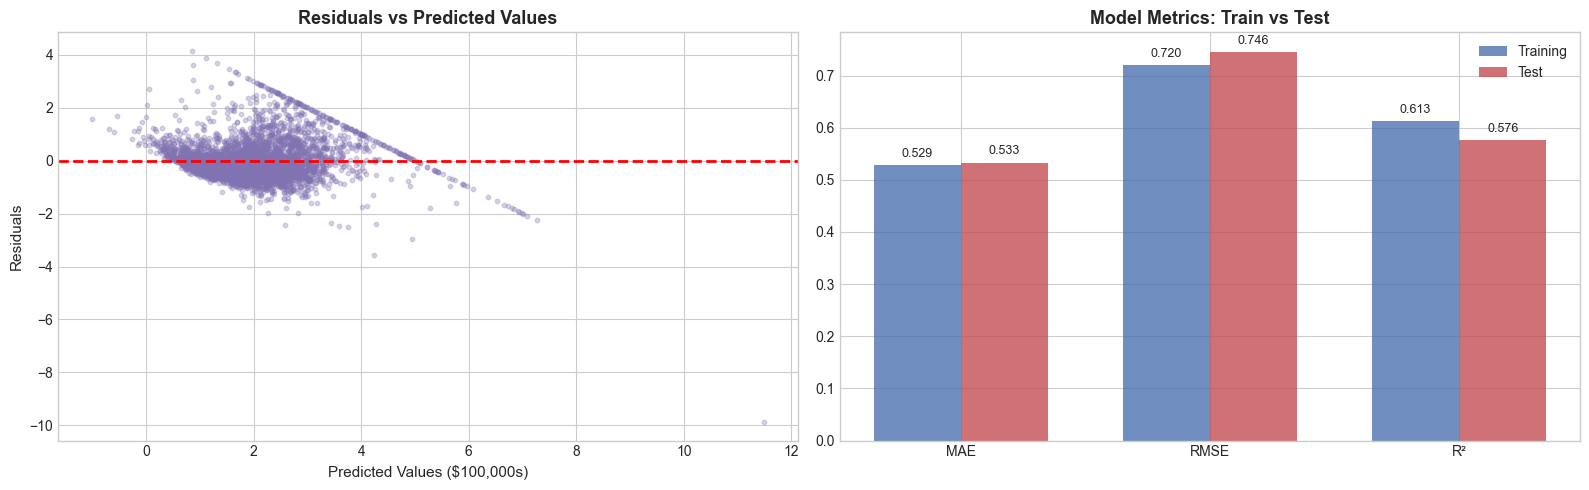

In [13]:
# Visualization 2: Residual plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Residuals vs Predicted
axes[0].scatter(y_test_pred, residuals, alpha=0.3, s=10, color='#8172B2')
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Values ($100,000s)', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Predicted Values', fontsize=13, fontweight='bold')

# Metrics bar chart
metrics_train = [train_mae, train_rmse, train_r2]
metrics_test  = [test_mae,  test_rmse,  test_r2]
labels = ['MAE', 'RMSE', 'R²']
x = np.arange(len(labels))
width = 0.35

bars1 = axes[1].bar(x - width/2, metrics_train, width, label='Training', color='#4C72B0', alpha=0.8)
bars2 = axes[1].bar(x + width/2, metrics_test, width, label='Test', color='#C44E52', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Model Metrics: Train vs Test', fontsize=13, fontweight='bold')
axes[1].legend()

for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('eval_residuals_and_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Saving the Model

In [14]:
# Save the trained model and scaler
model_data = {
    'model': model,
    'scaler': scaler,
    'feature_names': list(california.feature_names),
    'metrics': {
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    }
}

with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

size_kb = os.path.getsize('house_price_model.pkl') / 1024
print(f'✅ Model saved as house_price_model.pkl ({size_kb:.1f} KB)')
print(f'   Includes: LinearRegression model + StandardScaler + metadata')

✅ Model saved as house_price_model.pkl (1.3 KB)
   Includes: LinearRegression model + StandardScaler + metadata


---
## 8. Conclusions & Improvement Ideas

In [15]:
print('=' * 60)
print('  FINAL MODEL SUMMARY')
print('=' * 60)
print(f'  Model          : Linear Regression (OLS)')
print(f'  Dataset        : California Housing (20,640 samples)')
print(f'  Features       : 8')
print(f'  Train/Test     : 80% / 20% split')
print(f'  Preprocessing  : StandardScaler')
print()
print(f'  TEST METRICS:')
print(f'  ├─ MAE         : {test_mae:.4f} (avg error: ${test_mae*100000:,.0f})')
print(f'  ├─ RMSE        : {test_rmse:.4f} (${test_rmse*100000:,.0f})')
print(f'  └─ R² Score    : {test_r2:.4f} ({test_r2*100:.1f}% variance explained)')
print('=' * 60)

print()
print('💡 KEY INSIGHTS FROM EDA:')
print('  1. MedInc (median income) has the strongest positive correlation with house price')
print('  2. Latitude & Longitude strongly influence prices (coastal areas are more expensive)')
print('  3. AveBedrms has a slight negative correlation (larger blocks with many bedrooms tend to be cheaper)')
print('  4. No missing values found — dataset is clean')

print()
print('🚀 IMPROVEMENT IDEAS:')
print('  1. Feature Engineering  — create new features (e.g., rooms_per_person, income_per_room)')
print('  2. Outlier Removal      — cap extreme values in AveRooms, AveBedrms, Population')
print('  3. Advanced Models      — try Ridge, Lasso, RandomForest, or XGBoost')
print('  4. Hyperparameter Tuning— use GridSearchCV or RandomizedSearchCV')
print('  5. Cross-Validation     — use k-fold CV for more robust metric estimation')
print('  6. Log Transform Target — the target is slightly right-skewed; log transform may help')
print('  7. Polynomial Features  — add degree-2 polynomial features for non-linear patterns')

  FINAL MODEL SUMMARY
  Model          : Linear Regression (OLS)
  Dataset        : California Housing (20,640 samples)
  Features       : 8
  Train/Test     : 80% / 20% split
  Preprocessing  : StandardScaler

  TEST METRICS:
  ├─ MAE         : 0.5332 (avg error: $53,320)
  ├─ RMSE        : 0.7456 ($74,558)
  └─ R² Score    : 0.5758 (57.6% variance explained)

💡 KEY INSIGHTS FROM EDA:
  1. MedInc (median income) has the strongest positive correlation with house price
  2. Latitude & Longitude strongly influence prices (coastal areas are more expensive)
  3. AveBedrms has a slight negative correlation (larger blocks with many bedrooms tend to be cheaper)
  4. No missing values found — dataset is clean

🚀 IMPROVEMENT IDEAS:
  1. Feature Engineering  — create new features (e.g., rooms_per_person, income_per_room)
  2. Outlier Removal      — cap extreme values in AveRooms, AveBedrms, Population
  3. Advanced Models      — try Ridge, Lasso, RandomForest, or XGBoost
  4. Hyperparameter Tuni